In [3]:
import pandas as pd

df = pd.read_excel("Book1.xlsx",skiprows = 2)

arr = []
for i in df.columns:
    if "Unnamed" not in i:
        arr.append(i)
        

col_ = []

for i in range(len(arr)):
    col_.append('Dates' +  arr[i])
    col_.append('Open ' + arr[i])
    col_.append('Close ' + arr[i])
    col_.append('High ' + arr[i])
    col_.append('Low ' + arr[i])
    


df = pd.read_excel("Book1.xlsx",sheet_name = "Sheet1",skiprows = 3)

df.columns = col_


dict_curr = {}
for i in range(len(arr)):
    temp = df[['Dates'+ arr[i], 'Open ' + arr[i],'Low ' + arr[i], 'High ' + arr[i], 'Close ' + arr[i], ]]
    
    temp = temp.rename({'Dates'+ arr[i]: 'Date', 'Low ' + arr[i]: "Low", 'Close ' + arr[i]:'Close', 'Open ' + arr[i]:'Open', 'High ' + arr[i]: 'High'},axis = 1)
    temp = temp.set_index("Date").dropna()
    
    dict_curr[arr[i]]= temp

/var/folders/vg/l_37lnp90xj57y538k_5gzbh0000gn/T/ipykernel_73788/2316213395.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
/var/folders/vg/l_37lnp90xj57y538k_5gzbh0000gn/T/ipykernel_73788/2316213395.py:79: RuntimeWarning: divide by zero encountered in log
  return np.polyfit(np.log(lags), np.log(tau), 1)[0]


EURUSD Mean Reversion Stats:
{'ADF_pvalue': 0.7295195085275099, 'HalfLife': 314.1814633277376, 'Hurst': nan, 'OU_theta': 0.0022062001151127446, 'OU_sigma': 0.01430957849584701, 'ZScore_mean': -0.004569854301804985, 'ZScore_std': 1.2666571966473057}


/var/folders/vg/l_37lnp90xj57y538k_5gzbh0000gn/T/ipykernel_73788/2316213395.py:79: RuntimeWarning: divide by zero encountered in log
  return np.polyfit(np.log(lags), np.log(tau), 1)[0]


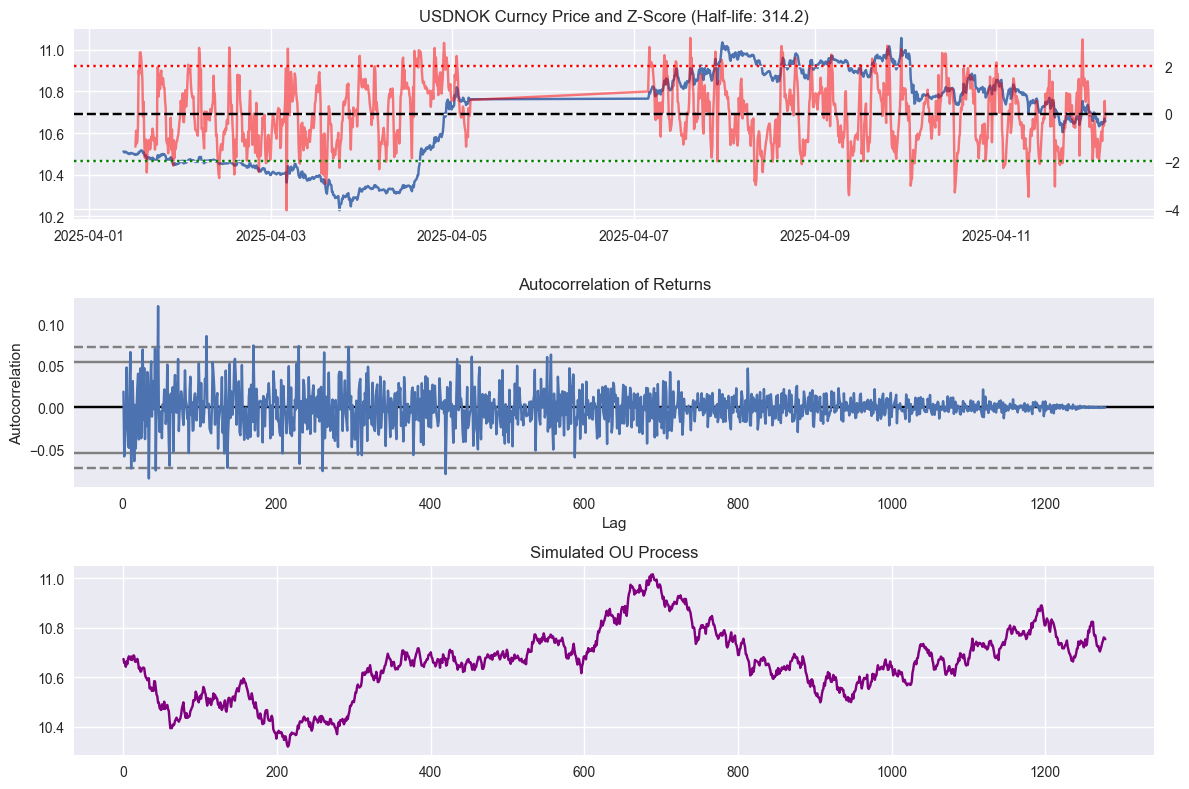


GBPUSD Momentum Stats:


,0
ACF1,0.018941
ACF5,0.047990
VarianceRatio,107.846715
Momentum_mean,0.000059
Momentum_std,0.002876
RSI_mean,49.308477
ADX_mean,NaN


2025-04-01 09:00:00   NaN
2025-04-01 09:10:00   NaN
2025-04-01 09:20:00   NaN
2025-04-01 09:30:00   NaN
2025-04-01 09:40:00   NaN
                       ..
1274                  NaN
1275                  NaN
1276                  NaN
1277                  NaN
1278                  NaN
Length: 2558, dtype: float64

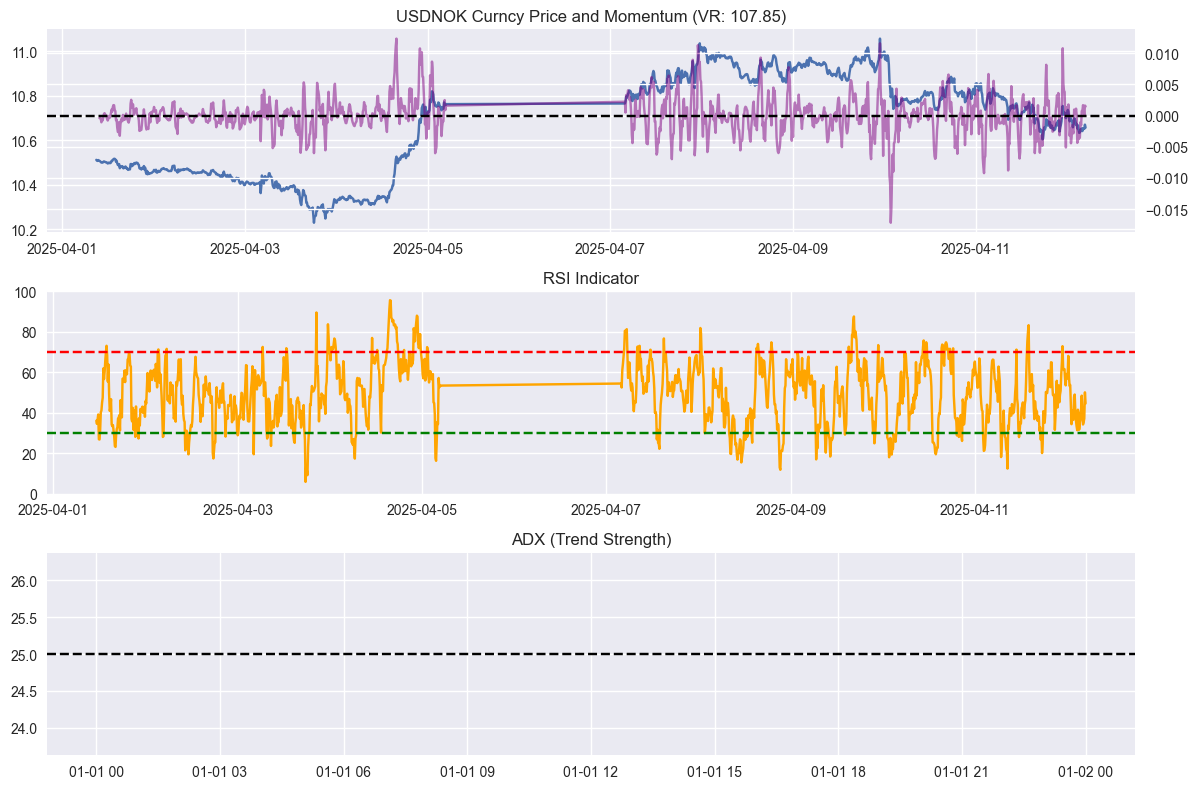

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, coint
from sklearn.linear_model import LinearRegression
plt.style.use('seaborn')

class IntradayStrategyAnalyzer:
    def __init__(self, ohlc_data, lookback=20):
        """
        ohlc_data: Dict of DataFrames with ['Open','High','Low','Close']
        lookback: Period for rolling calculations
        """
        self.data = {k: v.copy() for k,v in ohlc_data.items()}
        self.lookback = lookback
        self._preprocess_data()
    
    def _preprocess_data(self):
        """Calculate common metrics"""
        for pair in self.data:
            df = self.data[pair]
            df['Returns'] = df['Close'].pct_change()
            df['LogReturns'] = np.log(df['Close']/df['Close'].shift(1))
            df['Range'] = df['High'] - df['Low']
            df['Hour'] = df.index.hour
            
            # Rolling volatility
            df['Volatility'] = df['Returns'].rolling(self.lookback).std()
            
            # Time features
            df['DayOfWeek'] = df.index.dayofweek
            df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)
    
    # ======================
    # Mean Reversion Analytics
    # ======================
    
    def mean_reversion_stats(self, pair):
        """Comprehensive mean reversion statistics"""
        df = self.data[pair]
        
        # 1. Stationarity tests
        adf = adfuller(df['Close'].dropna())
        half_life = self._calculate_half_life(df['Close'])
        
        # 2. Rolling z-score
        mean = df['Close'].rolling(self.lookback).mean()
        std = df['Close'].rolling(self.lookback).std()
        df['ZScore'] = (df['Close'] - mean) / std
        
        # 3. Hurst exponent
        hurst = self._calculate_hurst(df['Close'])
        
        # 4. OU process parameters
        ou_params = self._estimate_ou_process(df['Close'])
        
        return {
            'ADF_pvalue': adf[1],
            'HalfLife': half_life,
            'Hurst': hurst,
            'OU_theta': ou_params['theta'],
            'OU_sigma': ou_params['sigma'],
            'ZScore_mean': df['ZScore'].mean(),
            'ZScore_std': df['ZScore'].std()
        }
    
    def _calculate_half_life(self, series):
        """Calculate half-life of mean reversion"""
        lag = series.shift(1).dropna()
        delta = series.diff().dropna()
        model = LinearRegression().fit(lag.values.reshape(-1,1), delta)
        return -np.log(2)/model.coef_[0]
    
    def _calculate_hurst(self, series):
        """Calculate Hurst exponent"""
        lags = range(2, 100)
        tau = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
        return np.polyfit(np.log(lags), np.log(tau), 1)[0]
    
    def _estimate_ou_process(self, series):
        """Estimate Ornstein-Uhlenbeck process parameters"""
        series = series.dropna()
        delta = series.diff().dropna()
        lag = series.shift(1).dropna()
        
        # OLS regression
        model = LinearRegression().fit(lag.values.reshape(-1,1), delta)
        theta = -model.coef_[0]
        mu = model.intercept_/theta
        residuals = delta - (model.intercept_ + model.coef_[0]*lag)
        sigma = np.std(residuals)
        
        return {'theta': theta, 'mu': mu, 'sigma': sigma}
    
    # ======================
    # Momentum Analytics
    # ======================
    
    def momentum_stats(self, pair):
        """Comprehensive momentum statistics"""
        df = self.data[pair]
        
        # 1. Autocorrelation analysis
        acf1 = df['Returns'].autocorr(lag=1)
        acf5 = df['Returns'].autocorr(lag=5)
        
        # 2. Variance ratio test
        vr = self._variance_ratio(df['Close'], lag=5)
        
        # 3. Rolling momentum metrics
        df['Momentum'] = df['Close'] / df['Close'].shift(5) - 1
        df['RSI'] = self._calculate_rsi(df['Close'])
        
        # 4. Trend strength
        adx = self._calculate_adx(df)
        
        return {
            'ACF1': acf1,
            'ACF5': acf5,
            'VarianceRatio': vr,
            'Momentum_mean': df['Momentum'].mean(),
            'Momentum_std': df['Momentum'].std(),
            'RSI_mean': df['RSI'].mean(),
            'ADX_mean': adx.mean()
        }
    
    def _variance_ratio(self, series, lag=5):
        """Variance ratio test for random walk"""
        returns = np.log(series).diff().dropna()
        var_1day = returns.var()
        var_lagday = (series - series.shift(lag)).dropna().var()/lag
        return var_lagday/var_1day
    
    def _calculate_rsi(self, series, period=14):
        """Relative Strength Index"""
        delta = series.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        
        avg_gain = gain.rolling(period).mean()
        avg_loss = loss.rolling(period).mean()
        
        rs = avg_gain/avg_loss
        return 100 - (100/(1+rs))
    
    def _calculate_adx(self, df, period=14):
        """Average Directional Index (simplified)"""
        tr = df['High'].combine(df['Close'].shift(1), max) - df['Low'].combine(df['Close'].shift(1), min)
        atr = tr.rolling(period).mean()
        
        up_move = df['High'] - df['High'].shift(1)
        down_move = df['Low'].shift(1) - df['Low']
        
        pos_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
        neg_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0)
        
        pos_di = 100 * pd.Series(pos_dm).rolling(period).mean() / atr
        neg_di = 100 * pd.Series(neg_dm).rolling(period).mean() / atr
        
        return abs(pos_di - neg_di) / (pos_di + neg_di) * 100
    
    # ======================
    # Cross-Pair Analysis
    # ======================
    
    def cross_pair_analysis(self, pair1, pair2):
        """Statistical arbitrage between two pairs"""
        s1 = self.data[pair1]['Close']
        s2 = self.data[pair2]['Close']
        
        # 1. Cointegration test
        coint_test = coint(s1, s2)
        
        # 2. Rolling correlation
        rolling_corr = s1.rolling(self.lookback).corr(s2)
        
        # 3. Spread analysis
        model = LinearRegression().fit(s1.values.reshape(-1,1), s2)
        spread = s2 - (model.intercept_ + model.coef_[0]*s1)
        spread_z = (spread - spread.mean())/spread.std()
        
        return {
            'Coint_pvalue': coint_test[1],
            'RollingCorr_mean': rolling_corr.mean(),
            'Spread_mean_reversion': self._calculate_half_life(spread),
            'Spread_stationary': adfuller(spread.dropna())[1] < 0.05
        }
    
    # ======================
    # Visualization Methods
    # ======================
    
    def plot_mean_reversion(self, pair):
        """Visualize mean reversion metrics"""
        stats = self.mean_reversion_stats(pair)
        df = self.data[pair]
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        
        # Price and z-score
        axes[0].plot(df['Close'], label='Price')
        axes[0].set_title(f'{pair} Price and Z-Score (Half-life: {stats["HalfLife"]:.1f})')
        ax2 = axes[0].twinx()
        ax2.plot(df['ZScore'], color='red', alpha=0.5, label='Z-Score')
        ax2.axhline(0, color='black', linestyle='--')
        ax2.axhline(2, color='red', linestyle=':')
        ax2.axhline(-2, color='green', linestyle=':')
        
        # ACF of returns
        pd.plotting.autocorrelation_plot(df['Returns'].dropna(), ax=axes[1])
        axes[1].set_title('Autocorrelation of Returns')
        
        # OU process simulation
        t = np.linspace(0, 100, 500)
        ou_process = self._simulate_ou(
            stats['OU_theta'], 
            stats['OU_sigma'], 
            df['Close'].mean(),
            len(df)
        )
        axes[2].plot(ou_process, color='purple')
        axes[2].set_title('Simulated OU Process')
        
        plt.tight_layout()
        plt.show()
    
    def _simulate_ou(self, theta, sigma, mu, n_steps):
        """Simulate Ornstein-Uhlenbeck process"""
        x = np.zeros(n_steps)
        x[0] = mu
        dt = 1
        
        for t in range(1, n_steps):
            x[t] = x[t-1] + theta*(mu - x[t-1])*dt + sigma*np.random.normal(0, np.sqrt(dt))
        
        return x
    
    def plot_momentum(self, pair):
        """Visualize momentum metrics"""
        stats = self.momentum_stats(pair)
        df = self.data[pair]
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        
        # Price and momentum
        axes[0].plot(df['Close'], label='Price')
        axes[0].set_title(f'{pair} Price and Momentum (VR: {stats["VarianceRatio"]:.2f})')
        ax2 = axes[0].twinx()
        ax2.plot(df['Momentum'], color='purple', alpha=0.5, label='5-Period Momentum')
        ax2.axhline(0, color='black', linestyle='--')
        
        # RSI
        axes[1].plot(df['RSI'], color='orange')
        axes[1].axhline(70, linestyle='--', color='red')
        axes[1].axhline(30, linestyle='--', color='green')
        axes[1].set_title('RSI Indicator')
        axes[1].set_ylim(0, 100)
        
        # ADX
        axes[2].plot(self._calculate_adx(df), color='blue')
        display(self._calculate_adx(df))
        
        axes[2].axhline(25, linestyle='--', color='black')
        axes[2].set_title('ADX (Trend Strength)')
        
        plt.tight_layout()
        plt.show()

# Example Usage
if __name__ == "__main__":

    
    # Initialize analyzer
    analyzer = IntradayStrategyAnalyzer(dict_curr)
    
    # Analyze mean reversion
    print("EURUSD Mean Reversion Stats:")
    print(analyzer.mean_reversion_stats('USDNOK Curncy'))
    analyzer.plot_mean_reversion('USDNOK Curncy')
    
#     # Analyze momentum
    print("\nGBPUSD Momentum Stats:")
    display(pd.DataFrame([analyzer.momentum_stats('USDNOK Curncy')]).T)
    analyzer.plot_momentum('USDNOK Curncy')
    
#     # Cross-pair analysis
#     print("\nEURUSD-GBPUSD Cross Analysis:")
#     print(analyzer.cross_pair_analysis('USDNOK Curncy', 'USDNZD Curncy'))

In [6]:
dict_curr.keys()

dict_keys(['USDSEK Curncy', 'USDJPY Curncy', 'USDNOK Curncy', 'USDCHF Curncy', 'USDGBP Curncy', 'USDNZD Curncy', 'USDAUD Curncy'])